In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 93 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv('/content/drive/MyDrive/인천e음_통합_일별.csv',encoding= 'utf-8')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import re


# 날짜 형식 변환
df['일자'] = pd.to_datetime(df['일자'])

# 캐시백 비율 숫자 추출
for column in ['연매출 3억원 이하', '연매출 3억~30억원', '연매출 30억원 초과']:
    df[column] = df[column].apply(lambda x: int(re.search(r'\d+', x).group()) if isinstance(x, str) else x)

# 지역 제외한 비율 조합 생성
value_columns = ['연매출 3억원 이하', '연매출 3억~30억원']
df['value_combination'] = df[value_columns].apply(tuple, axis=1)

# 고유한 비율 조합 추출
combinations = df['value_combination'].unique()

# 조합별 데이터프레임 생성 (전체 컬럼 유지)
combination_dfs = {}
for combo in combinations:
    # 해당 조합에 맞는 행 필터링, 모든 컬럼 포함
    df_combo = df[df['value_combination'] == combo].drop(columns='value_combination').copy()
    combination_dfs[combo] = df_combo

print("✅ 비율 조합별 데이터프레임 생성 완료!")
print(f"총 비율 조합 수: {len(combination_dfs)}")


✅ 비율 조합별 데이터프레임 생성 완료!
총 비율 조합 수: 4


In [ ]:
combo_key = (10, 10)
df_10=combination_dfs[combo_key]

combo_key = (10, 7)
df_7=combination_dfs[combo_key]

combo_key = (10, 5)
df_5=combination_dfs[combo_key]

In [ ]:
!apt-get update -qq
!apt-get install -y fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# 나눔폰트 사용
mpl.rc('font', family='NanumGothic')
mpl.rcParams['axes.unicode_minus'] = False


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 93 not upgraded.


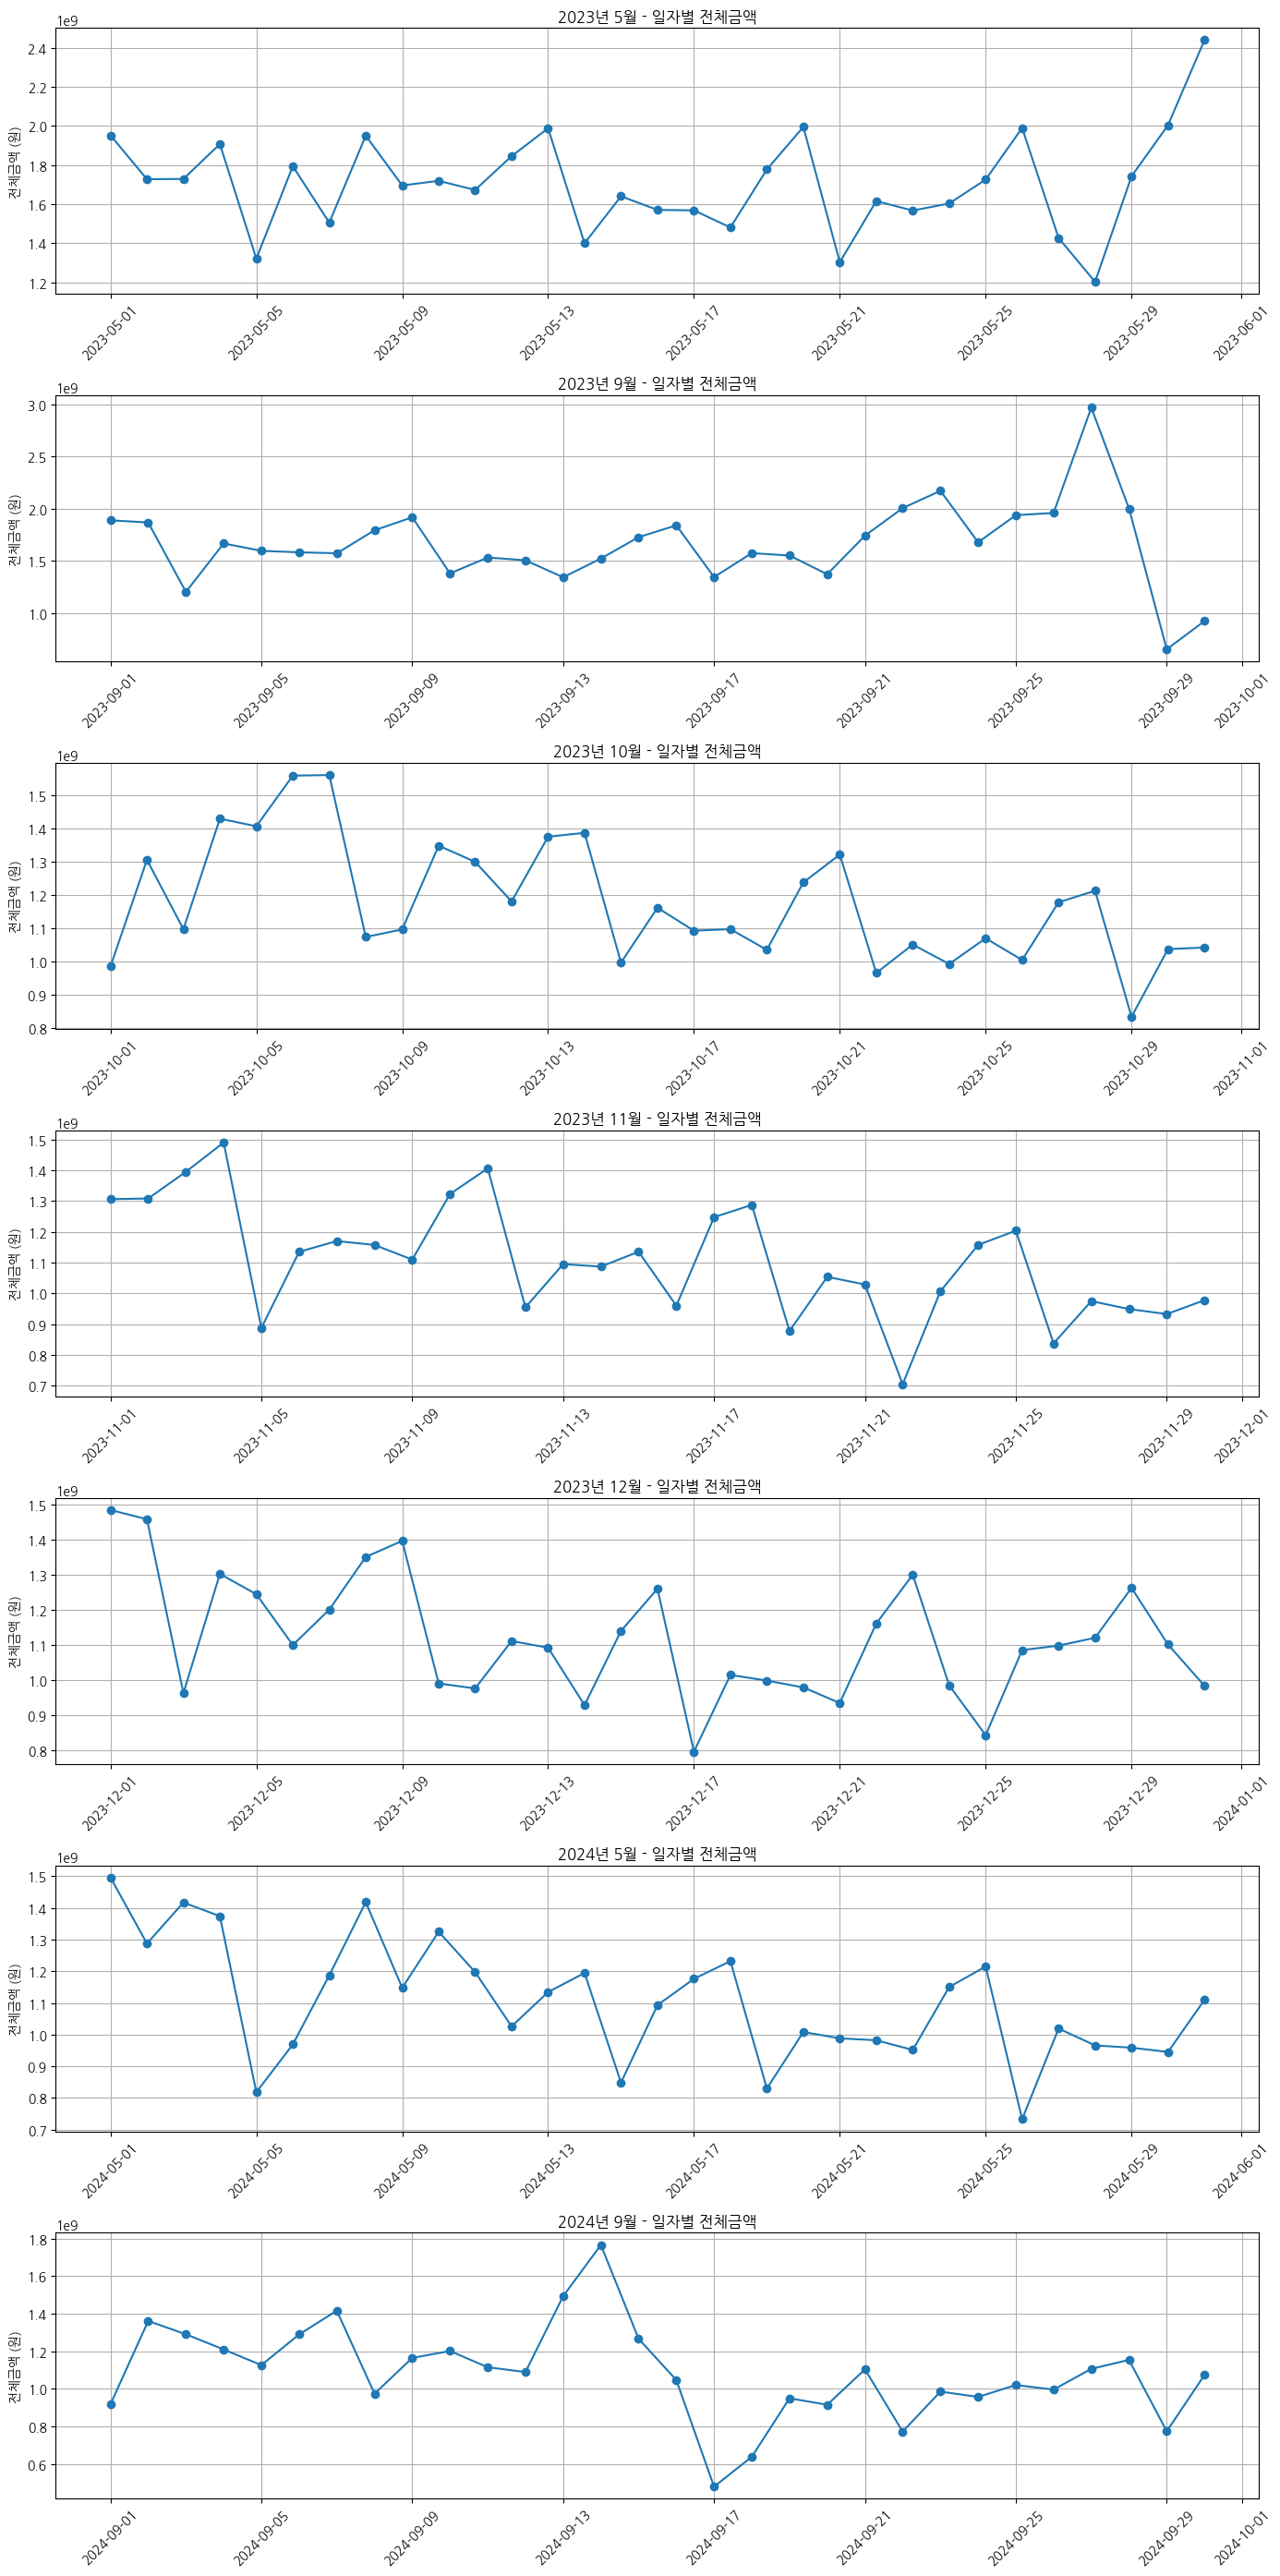

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib as mpl

# 나눔고딕 폰트 설정
mpl.rc('font', family='NanumGothic')  # 정확한 폰트명
mpl.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지


# 부평구 데이터 필터링
bupyeong = df_7[df_7['지역'] == '인천광역시 부평구'].copy()

# 년/월 컬럼 추가
bupyeong['년'] = bupyeong['일자'].dt.year
bupyeong['월'] = bupyeong['일자'].dt.month

# 유니크한 (년, 월) 조합 추출
year_months = bupyeong[['년', '월']].drop_duplicates().sort_values(['년', '월']).values

# 서브플롯 생성
n = len(year_months)
fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n), sharex=False)

if n == 1:
    axes = [axes]  # 서브플롯이 하나면 리스트로 감싸기

for i, (year, month) in enumerate(year_months):
    df_month = bupyeong[(bupyeong['년'] == year) & (bupyeong['월'] == month)].sort_values('일자')

    axes[i].plot(df_month['일자'], df_month['전체금액'], marker='o')
    axes[i].set_title(f"{year}년 {month}월 - 일자별 전체금액")
    axes[i].set_ylabel("전체금액 (원)")
    axes[i].grid(True)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
